# Renewable Energy Regression Analysis

**Two baseline regressions:**
1. **Capacity → Generation**: Does installed wind/solar capacity predict electricity generated?
2. **Capacity → Share**: Does installed capacity predict renewable electricity share (%)?

Both models use **country and year fixed effects** to control for persistent country-level differences and global trends over time.

**Data source:** `merged_capacity_data.csv` joined with `merged_renewables_data.csv` on Entity + Year.

## 1. Imports and Setup

Loads all required libraries and sets global chart style defaults.

In [2]:
import pandas as pd                        # Data loading, merging, and manipulation
import numpy as np                         # Numerical operations
import matplotlib.pyplot as plt            # Plotting
import statsmodels.formula.api as smf      # OLS regression with R-style formula syntax
import warnings
warnings.filterwarnings('ignore')

# Default chart size and style for all figures
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Load and Merge Data

Reads `merged_capacity_data.csv` (12 countries, has capacity in GW) and `merged_renewables_data.csv`
(251 countries, has electricity share %) and joins them on Entity + Year. Both files are needed
because neither alone has both capacity and share columns.

In [3]:
# Load the two source datasets:
#   merged_capacity_data.csv  — 12 countries, includes Wind/Solar Capacity (GW)
#   merged_renewables_data.csv — 251 countries, includes electricity share (%) but no capacity
cap = pd.read_csv('merged_capacity_data.csv')
ren = pd.read_csv('merged_renewables_data.csv')

# Inner join on Entity + Year to combine capacity with electricity share columns.
# We only pull the share columns from ren since cap already has generation (TWh).
df = cap.merge(
    ren[['Entity', 'Year', 'Renewables (% electricity)', 'Wind (% electricity)', 'Solar (% electricity)']],
    on=['Entity', 'Year'],
    how='inner'
)

print(f'Raw merged shape: {df.shape}')
print(f'Countries/regions: {df["Entity"].unique().tolist()}')

Raw merged shape: (684, 15)
Countries/regions: ['Africa', 'China', 'Denmark', 'France', 'Germany', 'India', 'Japan', 'Lower-middle-income countries', 'Mexico', 'Pakistan', 'United States', 'Upper-middle-income countries']


In [4]:
# Drop aggregate regions (not actual countries — would distort panel regression)
AGGREGATES = ['Africa', 'Lower-middle-income countries', 'Upper-middle-income countries']
df = df[~df['Entity'].isin(AGGREGATES)].copy()

# Rename to short snake_case names — statsmodels formula strings can't handle
# spaces or special characters in column names
df = df.rename(columns={
    'Wind Generation - TWh':      'wind_gen',
    'Solar Generation - TWh':     'solar_gen',
    'Hydro Generation - TWh':     'hydro_gen',
    'Wind Capacity':              'wind_cap',
    'Solar Capacity':             'solar_cap',
    'Wind (% equivalent primary energy)':       'wind_share_energy',
    'Solar (% equivalent primary energy)':      'solar_share_energy',
    'Renewables (% equivalent primary energy)': 'renew_share_energy',
    'Renewables (% electricity)': 'renew_share_elec',
    'Wind (% electricity)':       'wind_share_elec',
    'Solar (% electricity)':      'solar_share_elec',
})

# Drop rows missing capacity data — capacity columns only start around 1997
df_cap = df.dropna(subset=['wind_cap', 'solar_cap']).copy()

print(f'Analysis dataset: {df_cap.shape}')
print(f'Countries: {df_cap["Entity"].nunique()} — {df_cap["Entity"].unique().tolist()}')
print(f'Years: {df_cap["Year"].min()} – {df_cap["Year"].max()}')

Analysis dataset: (225, 15)
Countries: 9 — ['China', 'Denmark', 'France', 'Germany', 'India', 'Japan', 'Mexico', 'Pakistan', 'United States']
Years: 1997 – 2021


## 3. Exploratory Data Analysis

Visual checks before modeling: summary stats, time series by country, and capacity vs. generation scatters.

In [5]:
# Summary statistics for key variables — quick sanity check on scale and range
# before modeling. Large std relative to mean signals a few big countries (China, USA)
# dominate, which is why country fixed effects are important.
df_cap[['wind_cap', 'solar_cap', 'wind_gen', 'solar_gen', 'renew_share_elec']].describe().round(2)

,wind_cap,solar_cap,wind_gen,solar_gen,renew_share_elec
count,225.00,225.00,225.00,225.00,225.00
mean,19.30,13.13,39.01,14.81,20.45
std,42.41,36.22,87.06,40.26,12.70
min,0.00,0.00,0.00,0.00,4.21
25%,0.60,0.02,1.00,0.01,12.75
50%,3.48,0.44,6.58,0.56,17.25
75%,16.52,6.63,27.77,7.26,24.08
max,328.97,306.40,655.60,327.00,81.62


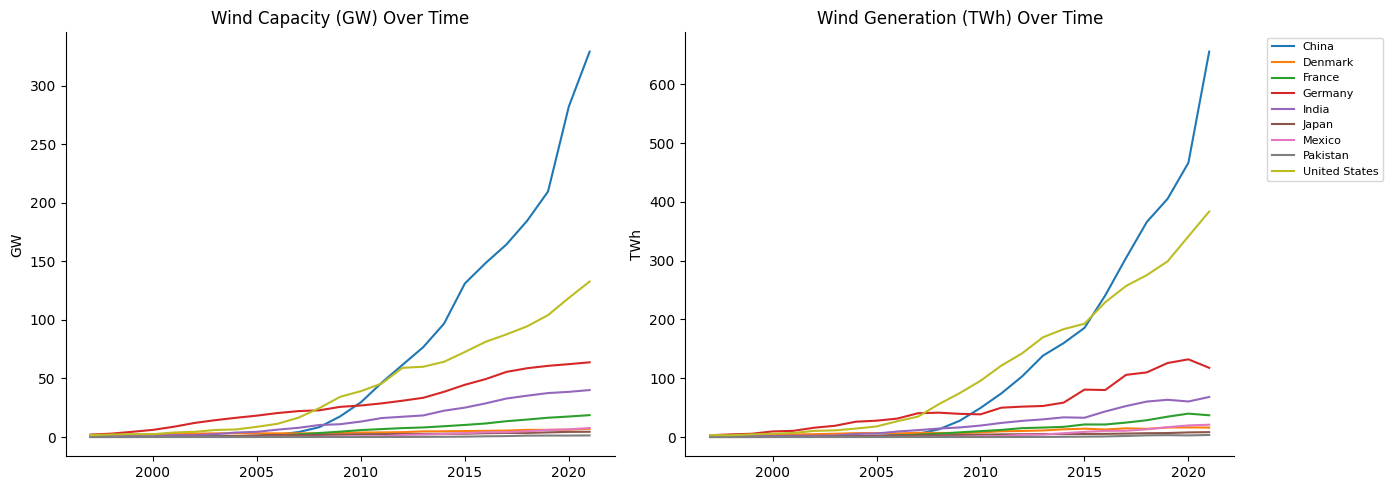

In [6]:
# Wind capacity (GW) and generation (TWh) over time, one line per country.
# Confirms capacity and generation track together and shows when each country
# began significant wind development.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for country in df_cap['Entity'].unique():
    sub = df_cap[df_cap['Entity'] == country]
    axes[0].plot(sub['Year'], sub['wind_cap'], label=country)
    axes[1].plot(sub['Year'], sub['wind_gen'], label=country)

axes[0].set_title('Wind Capacity (GW) Over Time')
axes[0].set_ylabel('GW')
axes[1].set_title('Wind Generation (TWh) Over Time')
axes[1].set_ylabel('TWh')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

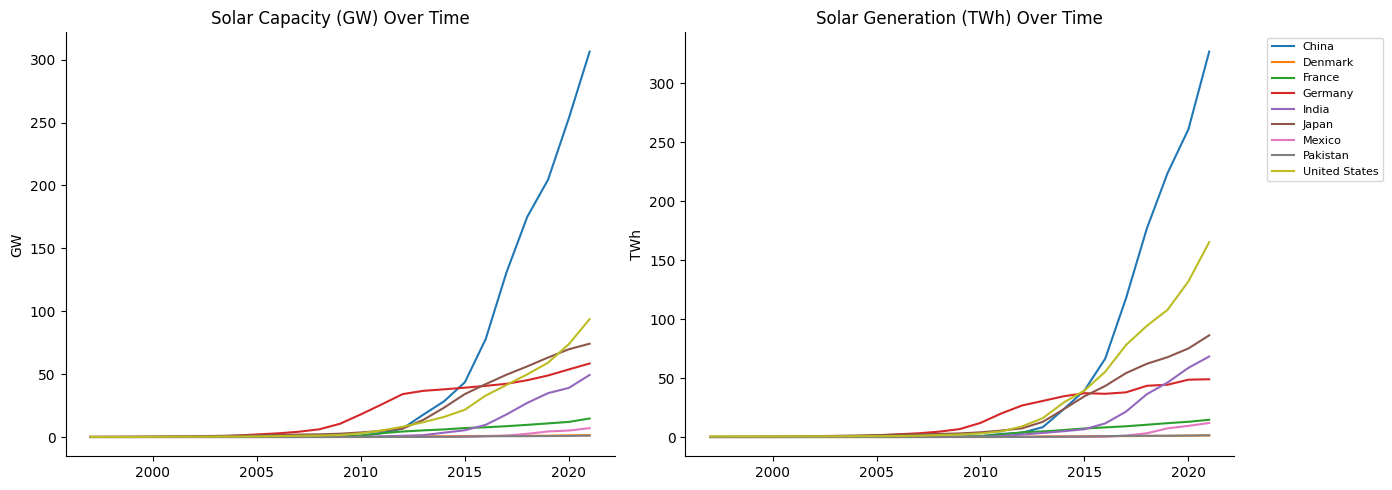

In [7]:
# Solar capacity (GW) and generation (TWh) over time, one line per country.
# Solar adoption started much later than wind (most countries post-2008),
# and China's buildout dominates after ~2013.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for country in df_cap['Entity'].unique():
    sub = df_cap[df_cap['Entity'] == country]
    axes[0].plot(sub['Year'], sub['solar_cap'], label=country)
    axes[1].plot(sub['Year'], sub['solar_gen'], label=country)

axes[0].set_title('Solar Capacity (GW) Over Time')
axes[0].set_ylabel('GW')
axes[1].set_title('Solar Generation (TWh) Over Time')
axes[1].set_ylabel('TWh')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

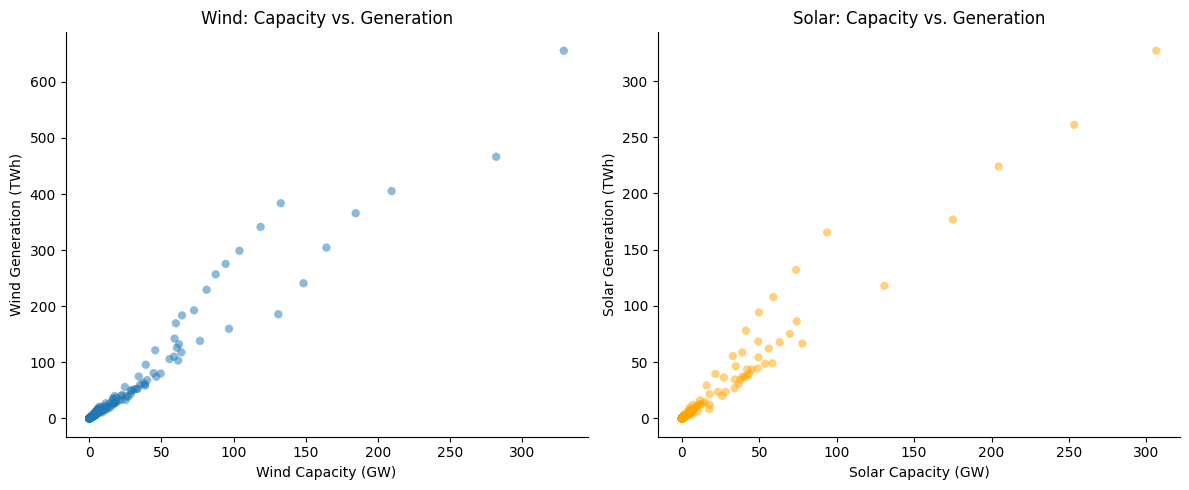

In [8]:
# Scatter of capacity vs. generation pooled across all countries and years.
# Confirms a positive relationship before modeling. Large countries (China, USA)
# will dominate the upper right — country fixed effects handle this in the regression.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_cap['wind_cap'], df_cap['wind_gen'], alpha=0.5, edgecolors='none')
axes[0].set_xlabel('Wind Capacity (GW)')
axes[0].set_ylabel('Wind Generation (TWh)')
axes[0].set_title('Wind: Capacity vs. Generation')

axes[1].scatter(df_cap['solar_cap'], df_cap['solar_gen'], alpha=0.5, color='orange', edgecolors='none')
axes[1].set_xlabel('Solar Capacity (GW)')
axes[1].set_ylabel('Solar Generation (TWh)')
axes[1].set_title('Solar: Capacity vs. Generation')

plt.tight_layout()
plt.show()

## 4. Regression 1: Capacity → Generation

**Model:**
$$\text{Generation}_{it} = \beta_1 \cdot \text{Capacity}_{it} + \alpha_i + \gamma_t + \varepsilon_{it}$$

Where $\alpha_i$ = country fixed effects and $\gamma_t$ = year fixed effects.

**Interpretation of $\beta_1$:** How many additional TWh of electricity are generated per additional GW of installed capacity, holding country-level differences and global year trends constant.

In [9]:
# Wind generation ~ wind capacity + country FE + year FE
#
# C(Entity) and C(Year) create dummy variables for each country and year,
# controlling for persistent country-level differences and global year trends.
# This means β1 is estimated from within-country variation only.
#
# cov_type='HC3' uses heteroskedasticity-robust standard errors since
# variance in generation differs greatly across small vs. large countries.
wind_gen_model = smf.ols(
    'wind_gen ~ wind_cap + C(Entity) + C(Year)',
    data=df_cap
).fit(cov_type='HC3')

print('=== WIND: Generation ~ Capacity + Country FE + Year FE ===')
print(f'N = {int(wind_gen_model.nobs)}')
print(f'R² = {wind_gen_model.rsquared:.4f}    Adj. R² = {wind_gen_model.rsquared_adj:.4f}')
print()

# Filter to show only the capacity coefficient — not all the FE dummy coefficients
key_vars = [v for v in wind_gen_model.params.index if 'cap' in v.lower()]
print(wind_gen_model.summary2().tables[1].loc[key_vars])

=== WIND: Generation ~ Capacity + Country FE + Year FE ===
N = 225
R² = 0.9704    Adj. R² = 0.9653

             Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
wind_cap  1.957807  0.105333  18.586867  4.104670e-77  1.751358  2.164255


In [10]:
# Solar generation ~ solar capacity + country FE + year FE
#
# Run separately from wind rather than combined to avoid multicollinearity
# (countries that build wind also tend to build solar). Gives a clean estimate
# of solar's own capacity-to-generation relationship.
solar_gen_model = smf.ols(
    'solar_gen ~ solar_cap + C(Entity) + C(Year)',
    data=df_cap
).fit(cov_type='HC3')

print('=== SOLAR: Generation ~ Capacity + Country FE + Year FE ===')
print(f'N = {int(solar_gen_model.nobs)}')
print(f'R² = {solar_gen_model.rsquared:.4f}    Adj. R² = {solar_gen_model.rsquared_adj:.4f}')
print()

key_vars = [v for v in solar_gen_model.params.index if 'cap' in v.lower()]
print(solar_gen_model.summary2().tables[1].loc[key_vars])

=== SOLAR: Generation ~ Capacity + Country FE + Year FE ===
N = 225
R² = 0.9730    Adj. R² = 0.9683

              Coef.  Std.Err.          z  P>|z|    [0.025    0.975]
solar_cap  1.060289  0.024543  43.201075    0.0  1.012185  1.108392


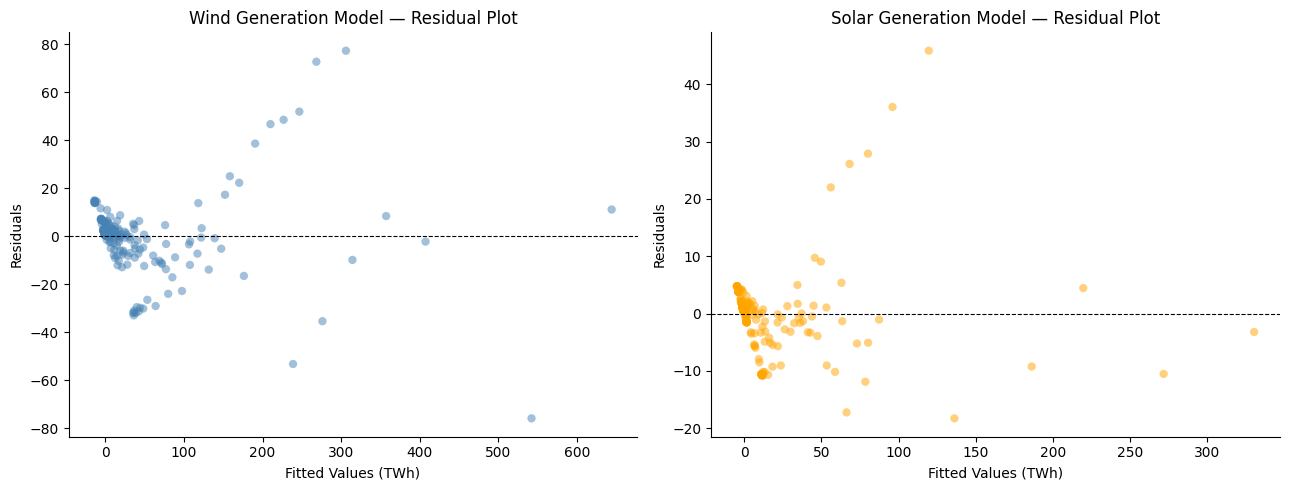

In [11]:
# Residual plots (fitted values vs. residuals) for both generation models.
# Residuals should be randomly scattered around zero — a fan shape would indicate
# heteroskedasticity, and a curve would suggest a non-linear relationship.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, label, color in zip(
    axes,
    [wind_gen_model, solar_gen_model],
    ['Wind', 'Solar'],
    ['steelblue', 'orange']
):
    ax.scatter(model.fittedvalues, model.resid, alpha=0.5, color=color, edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Fitted Values (TWh)')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{label} Generation Model — Residual Plot')

plt.tight_layout()
plt.show()

## 5. Regression 3: Capacity → Renewable Electricity Share

**Model:**
$$\text{Renewables\%}_{it} = \beta_1 \cdot \text{WindCap}_{it} + \beta_2 \cdot \text{SolarCap}_{it} + \alpha_i + \gamma_t + \varepsilon_{it}$$

**Interpretation:** How many additional percentage points of electricity share come from each additional GW of wind or solar capacity, controlling for country differences and year trends.

This is a more policy-relevant question — does building capacity actually shift the energy mix?

In [12]:
# Renewable electricity share ~ wind capacity + solar capacity + country FE + year FE
#
# More policy-relevant than Regression 1: asks whether building capacity actually
# shifts the energy mix, not just whether capacity produces electricity.
# Including both wind_cap and solar_cap together lets us estimate each technology's
# marginal contribution to share while holding the other constant.
df_share = df_cap.dropna(subset=['renew_share_elec']).copy()
print(f'N for share regression: {len(df_share)}')

share_model = smf.ols(
    'renew_share_elec ~ wind_cap + solar_cap + C(Entity) + C(Year)',
    data=df_share
).fit(cov_type='HC3')

print()
print('=== Renewables (% electricity) ~ Wind Cap + Solar Cap + Country FE + Year FE ===')
print(f'N = {int(share_model.nobs)}')
print(f'R² = {share_model.rsquared:.4f}    Adj. R² = {share_model.rsquared_adj:.4f}')
print()

key_vars = [v for v in share_model.params.index if 'cap' in v.lower()]
print(share_model.summary2().tables[1].loc[key_vars])

N for share regression: 225

=== Renewables (% electricity) ~ Wind Cap + Solar Cap + Country FE + Year FE ===
N = 225
R² = 0.6510    Adj. R² = 0.5886

              Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
wind_cap  -0.015929  0.021891 -0.727637  0.466836 -0.058835  0.026977
solar_cap -0.004067  0.036115 -0.112618  0.910334 -0.074852  0.066717


In [13]:
# Wind-only and solar-only versions of the share regression as a robustness check.
# If coefficients are larger here than in the joint model, it suggests wind and solar
# capacity are correlated and the joint model is splitting the shared effect between them.
wind_share_model = smf.ols(
    'renew_share_elec ~ wind_cap + C(Entity) + C(Year)',
    data=df_share
).fit(cov_type='HC3')

solar_share_model = smf.ols(
    'renew_share_elec ~ solar_cap + C(Entity) + C(Year)',
    data=df_share
).fit(cov_type='HC3')

print('=== Wind Capacity Only ===')
key = [v for v in wind_share_model.params.index if 'cap' in v.lower()]
print(wind_share_model.summary2().tables[1].loc[key])

print()
print('=== Solar Capacity Only ===')
key = [v for v in solar_share_model.params.index if 'cap' in v.lower()]
print(solar_share_model.summary2().tables[1].loc[key])

=== Wind Capacity Only ===
             Coef.  Std.Err.         z    P>|z|    [0.025    0.975]
wind_cap -0.019203   0.01635 -1.174511  0.24019 -0.051248  0.012842

=== Solar Capacity Only ===
              Coef.  Std.Err.         z     P>|z|   [0.025    0.975]
solar_cap -0.019982  0.021775 -0.917672  0.358791 -0.06266  0.022696


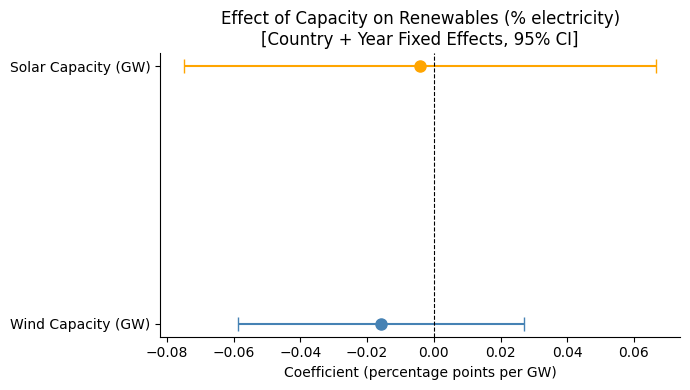

In [14]:
# Coefficient plot for the joint share model with 95% confidence intervals.
# Dots are point estimates; bars are the CI. If a bar does not cross the dashed
# zero line, the effect is statistically significant at the 5% level.
coef_names  = ['wind_cap', 'solar_cap']
coefs       = share_model.params[coef_names]
conf        = share_model.conf_int().loc[coef_names]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue', 'orange']
for i, (name, color) in enumerate(zip(coef_names, colors)):
    ax.errorbar(
        x=coefs[name],
        y=i,
        xerr=[[coefs[name] - conf.loc[name, 0]], [conf.loc[name, 1] - coefs[name]]],
        fmt='o', color=color, capsize=5, markersize=8
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Wind Capacity (GW)', 'Solar Capacity (GW)'])
ax.set_xlabel('Coefficient (percentage points per GW)')
ax.set_title('Effect of Capacity on Renewables (% electricity)\n[Country + Year Fixed Effects, 95% CI]')
plt.tight_layout()
plt.show()

## 6. Summary Table

Quick comparison of key coefficients across all four models.

In [15]:
# Pulls the key coefficient, standard error, p-value, R², and N from each model
# into one comparison table. p-value column is 'P>|z|' (not 'P>|t|') because
# HC3 robust standard errors produce z-statistics instead of t-statistics.
def extract_row(model, var, label):
    t = model.summary2().tables[1]
    row = t.loc[var]
    p_col = "P>|z|" if "P>|z|" in row.index else "P>|t|"
    return {
        "Model": label,
        "Coefficient": round(row["Coef."], 4),
        "Std Error": round(row["Std.Err."], 4),
        "p-value": round(row[p_col], 4),
        "R²": round(model.rsquared, 4),
        "N": int(model.nobs)
    }

summary = pd.DataFrame([
    extract_row(wind_gen_model,   "wind_cap",  "Wind Generation ~ Wind Cap"),
    extract_row(solar_gen_model,  "solar_cap", "Solar Generation ~ Solar Cap"),
    extract_row(share_model,      "wind_cap",  "Renewables % ~ Wind Cap + Solar Cap (wind)"),
    extract_row(share_model,      "solar_cap", "Renewables % ~ Wind Cap + Solar Cap (solar)"),
])

summary

,Model,Coefficient,Std Error,p-value,R²,N
0,Wind Generation ~ Wind Cap,1.9578,0.1053,0.0000,0.9704,225
1,Solar Generation ~ Solar Cap,1.0603,0.0245,0.0000,0.9730,225
2,Renewables % ~ Wind Cap + Solar Cap (wind),-0.0159,0.0219,0.4668,0.6510,225
3,Renewables % ~ Wind Cap + Solar Cap (solar),-0.0041,0.0361,0.9103,0.6510,225


## 7. Notes and Next Steps

**Limitations of these baseline models:**
- Only 9 countries with capacity data — limits generalizability
- No lagged variables — capacity built today generates electricity next year, not instantly
- Capacity and generation are mechanically related (more capacity → more generation by definition), so the regression 1 coefficients largely capture a physical relationship rather than a behavioral one

**Suggested extensions:**
- Add **lagged capacity** (1–3 year lag) to better capture the deployment-to-generation timeline
- Separate regressions **per country** to see if the capacity-generation relationship differs (e.g., China vs. Denmark)
- Use the broader `merged_renewables_data.csv` (251 countries) for regression 3 using lagged generation as a proxy for capacity
- Interaction terms: does wind capacity have a different effect on share in high-hydro vs. low-hydro countries?